# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

# Loading the dataset

In [2]:
# Creating database connection

In [3]:
conn = sqlite3.connect('inventory.db')

In [4]:
# Fetching Vendor Summary

In [5]:
df=pd.read_sql_query("Select * from vendor_sales_summary",conn)

In [6]:
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrices,totalExciseTax,FreightCost,GrossProfit,ProfitMargin,stockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


# EXPLORATORY DATA ANALYSIS

### - Previously,We examined the various tables in the database to identify key variable, understand their relationship and determine which ones should be included in the final analysis
### - In this Phase of EDA, we will analyze the resultant tableto gain insights into the distribution of each column.this will helps us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

# Summary Statistics

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrices,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


In [8]:
# Distribution Plot For Numerical Columns
numerical_cols=df.select_dtypes(include=np.number).columns
numerical_cols

Index(['VendorNumber', 'Brand', 'PurchasePrice', 'ActualPrice', 'volume',
       'TotalPurchaseQuantity', 'TotalPurchaseDollars', 'TotalSalesQuantity',
       'TotalSalesDollars', 'TotalSalesPrices', 'totalExciseTax',
       'FreightCost', 'GrossProfit', 'ProfitMargin', 'stockTurnover',
       'SalesToPurchaseRatio'],
      dtype='object')

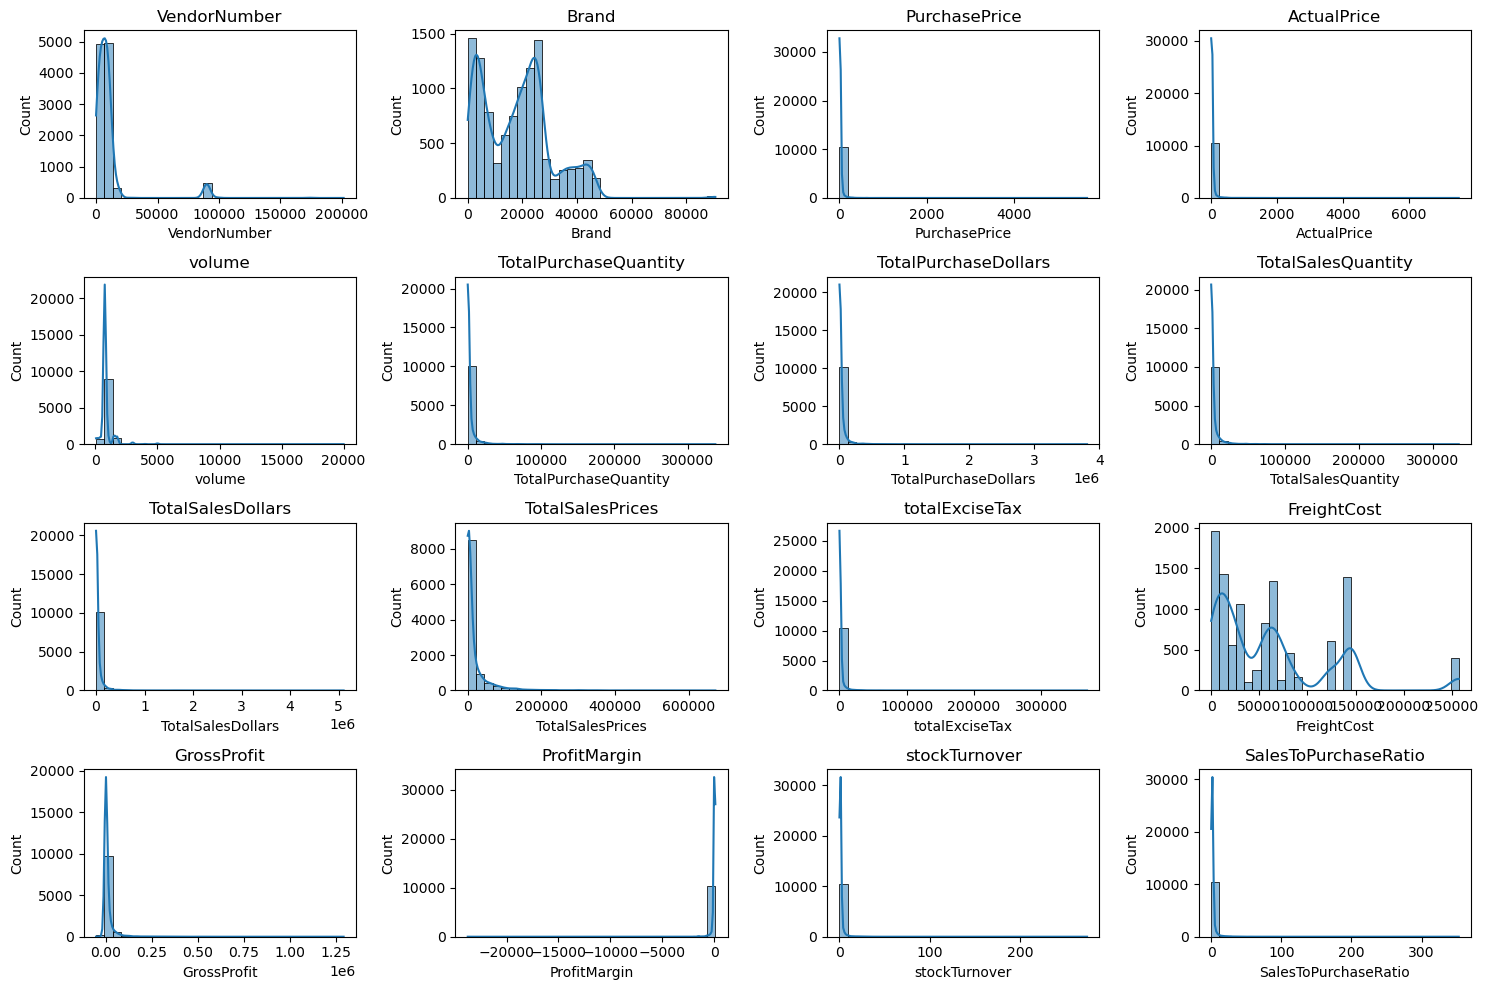

In [9]:
plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

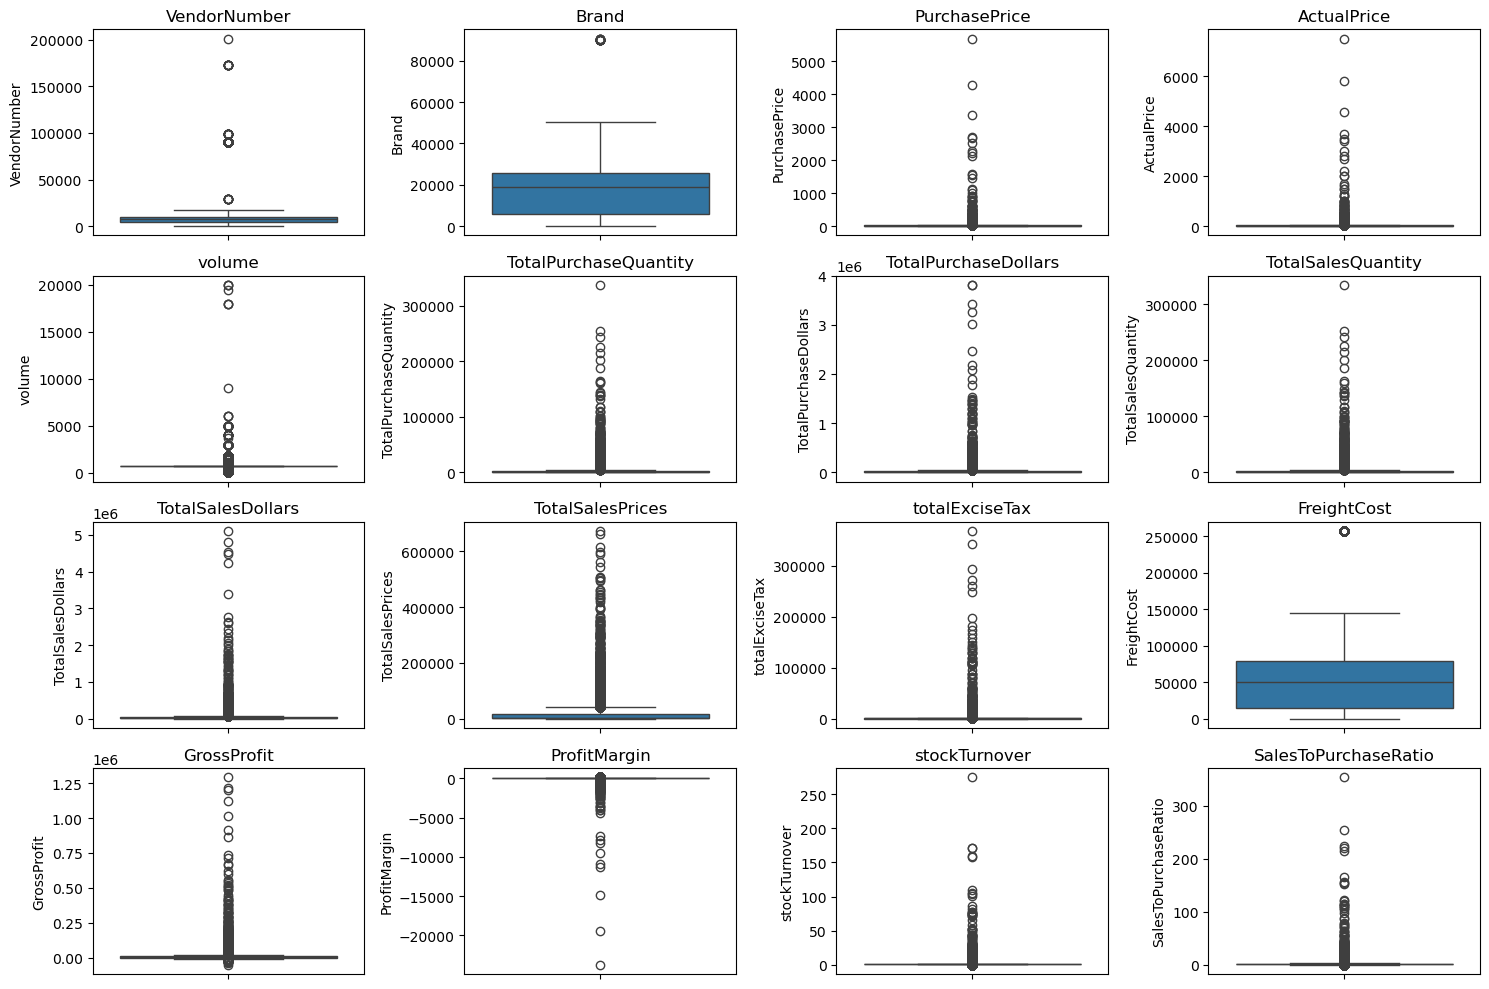

In [10]:
# Outlier detection With boxplot
plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## Summary Statistics Insights:
### Negative & Zero Values:
#### - Gross Profit: Minimum Value is -52,002.78, indicating losses.some products or transactions may be selling at a loss due to high cost or selling at discounts lower than purchase Price.
#### - Profit Margin:Has a minimum of - ∞ , which suggests cases where revenue is zero or even than costs
#### - TotalSalesQuantity & Sales dollars:Minimum values are 0 meaning some products were purchased bnut never sold. these colud be slow_moving or absolete Stock.
### Outliers indicated by High Standard Deviations
#### - Purchase& Actual Prices : The Max Values(5,681.81& 7,499.99) are significantly highes than the mean (24.39 &35.64) indicating Potential premium products.
#### - FreightCost : Huge variation , from0.09 to 257,032.07 suggest logistics inefficinecises or bulk Shipments.
#### - Stock Turnover : Ranges from 0 to 274.5 implying some products sell extremely fast while others remian in stock, indefinitely.Value more than1 indicates that sold quantirty for that product is higher than purchased quantity due to either sales are being fulfilled from older stock

In [11]:
# Let's filter the data by removing inconsistencies
df=pd.read_sql_query("""
    SELECT *
    FROM vendor_sales_summary
    WHERE GrossProfit > 0
    AND ProfitMargin > 0
    AND TotalSalesQuantity > 0 """,conn)

In [12]:
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrices,totalExciseTax,FreightCost,GrossProfit,ProfitMargin,stockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


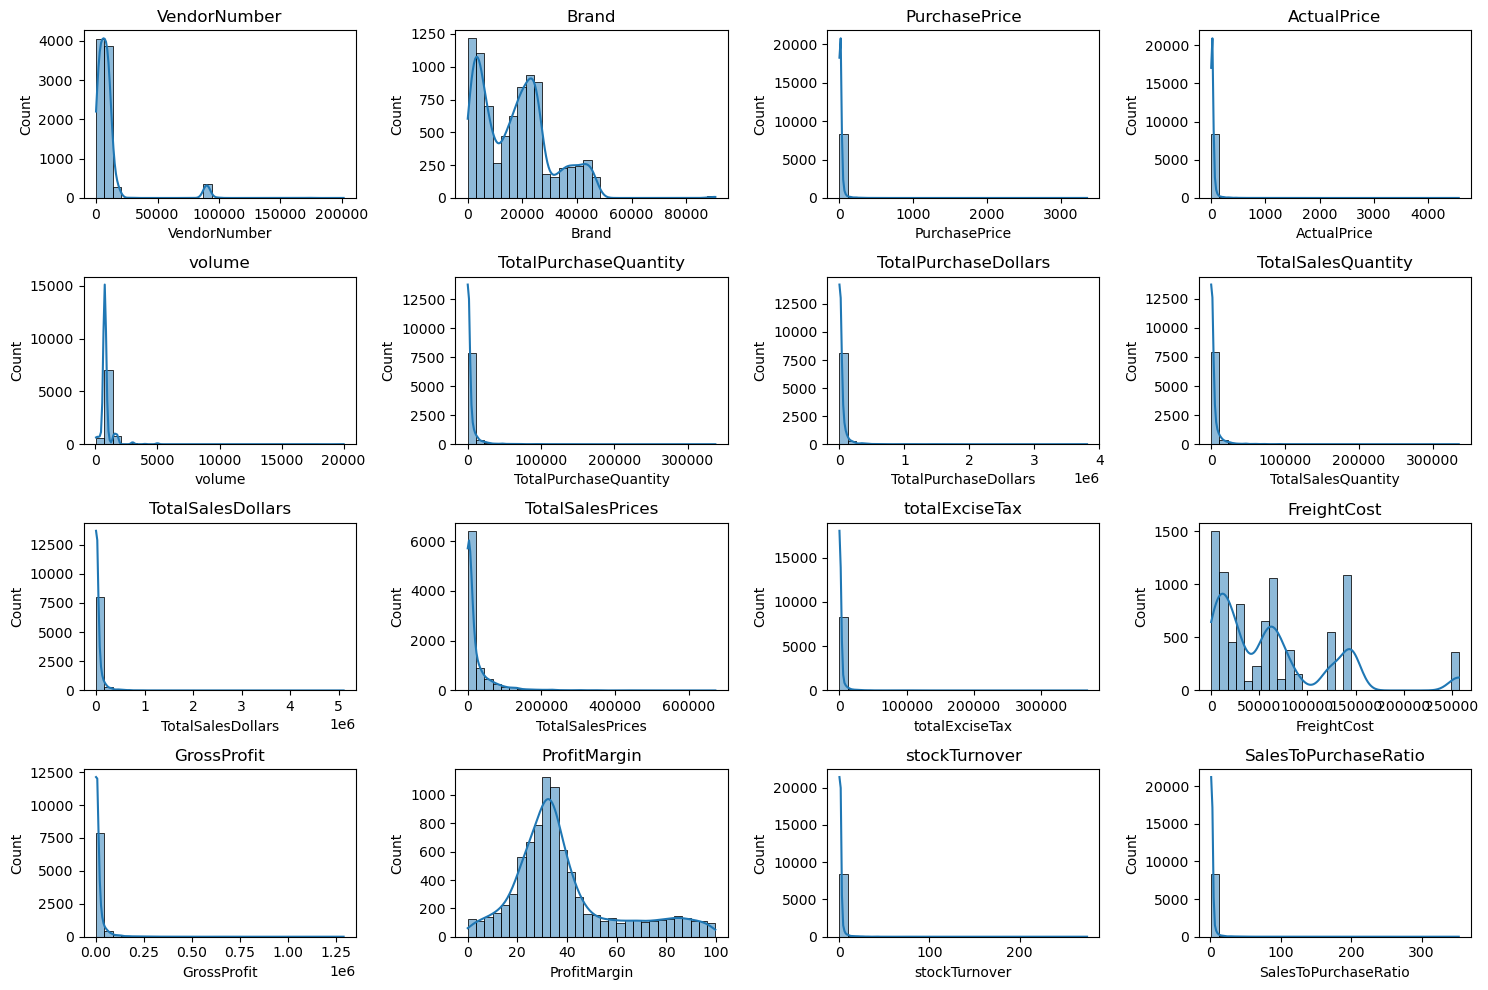

In [13]:
# Distribution Plot For Numerical Columns
numerical_cols=df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

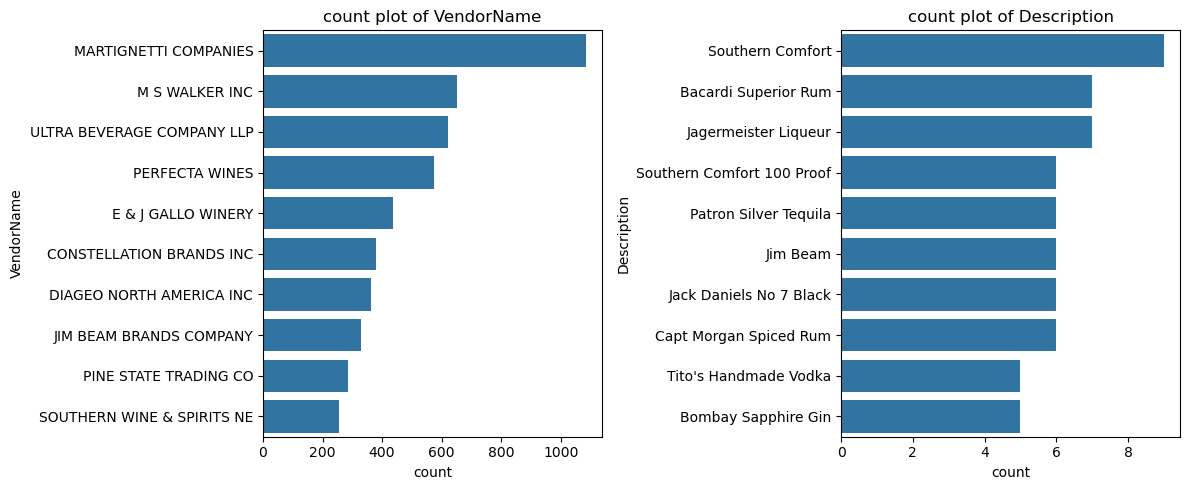

In [14]:
# Count Plots for categorical columns
categorical_cols = ["VendorName","Description"]
plt.figure(figsize=(12,5))
for i ,col  in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col],order=df[col].value_counts().index[:10])
    plt.title(f"count plot of {col}")
plt.tight_layout()
plt.show()


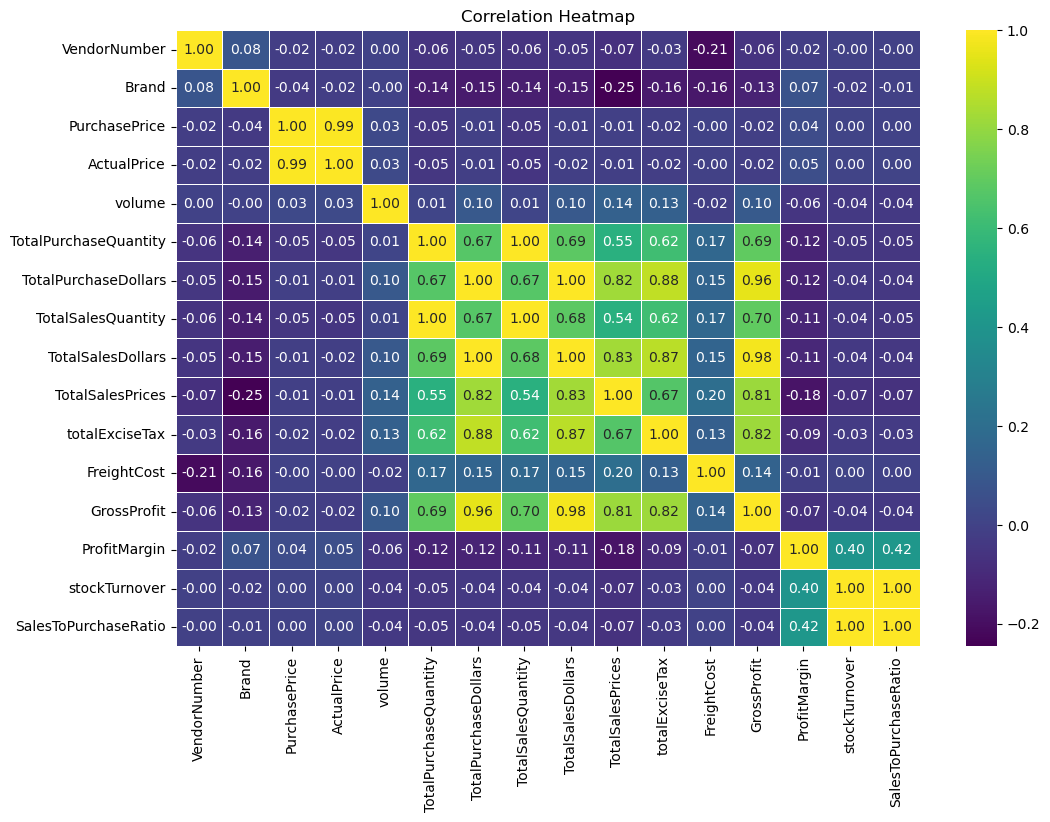

In [15]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
correlation_matrix=df[numerical_cols].corr()
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",
            cmap="viridis",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# CORRELATION INSIGHTS
### - PURCHASE PRICE has weak correlation with TotalSalesDollars(-0.012) and GROSS PROFIT (-0.016) Suggesting that Price Variations do not significantly impact Sales revenue or Profit.
### - STRONG CORRELATION between total purchase Quantity and total sales quantity(0.999),Confirming efficient inventory turnover.
### - NEGATIVE CORRELATION between Profit Margin & Total Sales Price (-0.179) suggests that as sales Price increase ,margin decrease,possible due to competitive pricing pressures.
### - STOCK TRUNOVER  has weak negative correlation with both gross profit(-0.038) and profit margin(-0.055) ,indicating that faster turnover does not necessarily results in higher Profitability.

# DATA ANALYSIS
#### - Identify Brands that needsPromotional or pricing Adjustments which exhibit lower sales Performance but higher profit margins.

In [16]:
brand_performance = df.groupby('Description').agg({"TotalSalesDollars":"sum","ProfitMargin":"mean"}).reset_index()

In [17]:
lower_sales_threshold = brand_performance["TotalSalesDollars"].quantile(0.15)
high_sales_threshold = brand_performance["ProfitMargin"].quantile(0.85)

In [18]:
#Filter brandswith low sales but high profit margins
target_brands = brand_performance[(brand_performance["TotalSalesDollars"] <= lower_sales_threshold) &
    (brand_performance["ProfitMargin"] >= high_sales_threshold)]
print("Brands With Low_sales but High Profit Margins")
display(target_brands.sort_values("TotalSalesDollars"))

Brands With Low_sales but High Profit Margins


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [19]:
brand_performance=brand_performance[brand_performance["TotalSalesDollars"]<1000]

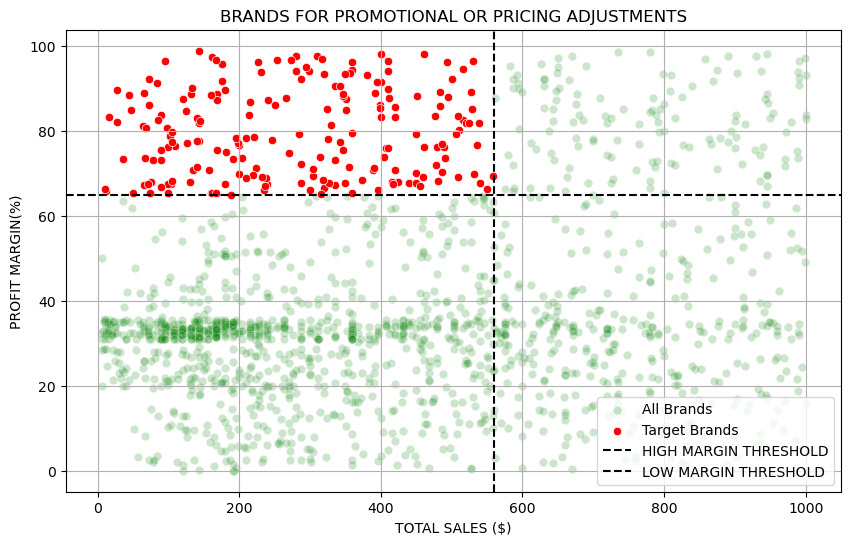

In [20]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance,x ="TotalSalesDollars",y ="ProfitMargin",color="green",label="All Brands",alpha=0.2)
sns.scatterplot(data=target_brands,x ="TotalSalesDollars",y ="ProfitMargin",color="Red",label="Target Brands")
plt.axhline(high_sales_threshold,linestyle="--",color="black",label ="HIGH MARGIN THRESHOLD")
plt.axvline(lower_sales_threshold,linestyle="--",color="black",label ="LOW MARGIN THRESHOLD")
plt.xlabel("TOTAL SALES ($)")
plt.ylabel("PROFIT MARGIN(%)")
plt.title("BRANDS FOR PROMOTIONAL OR PRICING ADJUSTMENTS")
plt.grid()
plt.legend()
plt.show()


# which Vendors and brands demonstarte the highest sales performance

In [21]:
# Top Vendor & Brands by Sales Performance
top_vendor=df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands=df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendor
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [22]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value/1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value/1_000:.2f}K"
    else:
        return str(value)


In [23]:
top_brands.apply(lambda x:format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

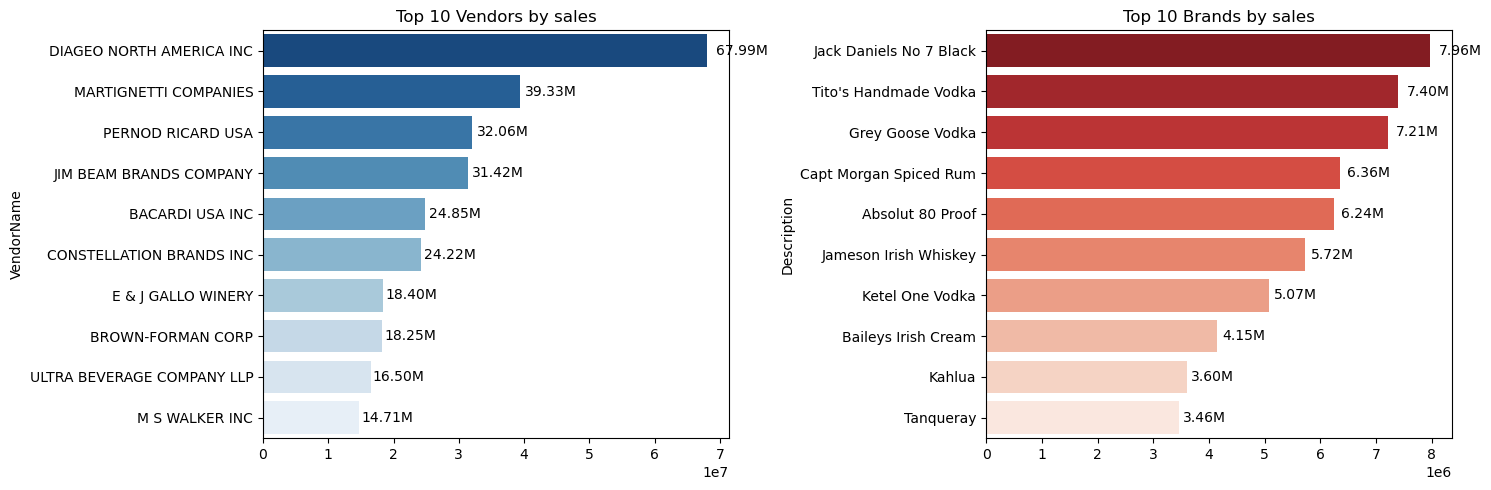

In [24]:
plt.figure(figsize=(15, 5))

# Plot for top vendor
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendor.index, x=top_vendor.values, palette="Blues_r")
plt.title("Top 10 Vendors by sales")
for bar in ax1.patches:
    # FIXED: Changed bar.get_width()/2 to bar.get_height()/2
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + (bar.get_height() / 2),
        format_dollars(bar.get_width()),
        ha="left",
        va="center",
        fontsize=10,
        color="black",
    )

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(
    y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r"
)
plt.title("Top 10 Brands by sales")
for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha="left",
        va="center",
        fontsize=10,
        color="black",
    )

plt.tight_layout()
plt.show()

In [25]:
# which vendor Contribute the most to total purchase dollars?

In [26]:
Vendor_performance=df.groupby("VendorName").agg({"TotalPurchaseDollars":"sum","GrossProfit":"sum","TotalSalesDollars":"sum"}).reset_index()
Vendor_performance["PurchaseContribution%"]=Vendor_performance["TotalPurchaseDollars"]/Vendor_performance["TotalPurchaseDollars"].sum()

In [27]:
Vendor_performance.sort_values("PurchaseContribution%",ascending=False)
Vendor_performance=round(Vendor_performance.sort_values("PurchaseContribution%",ascending=False),2)

In [28]:
# Display top 10 Vendor
top_vendor=Vendor_performance.head(10)
top_vendor["TotalSalesdollars"]=top_vendor["TotalSalesDollars"].apply(format_dollars)
top_vendor["TotalPurchasedollars"]=top_vendor["TotalPurchaseDollars"].apply(format_dollars)
top_vendor["GrossProfit"]=top_vendor["GrossProfit"].apply(format_dollars)
top_vendor["PurchaseContribution%"].sum()
# Calculate cumulative sum from the actual contribution column
top_vendor["cumulative_contribution%"] = top_vendor["PurchaseContribution%"].cumsum()*100

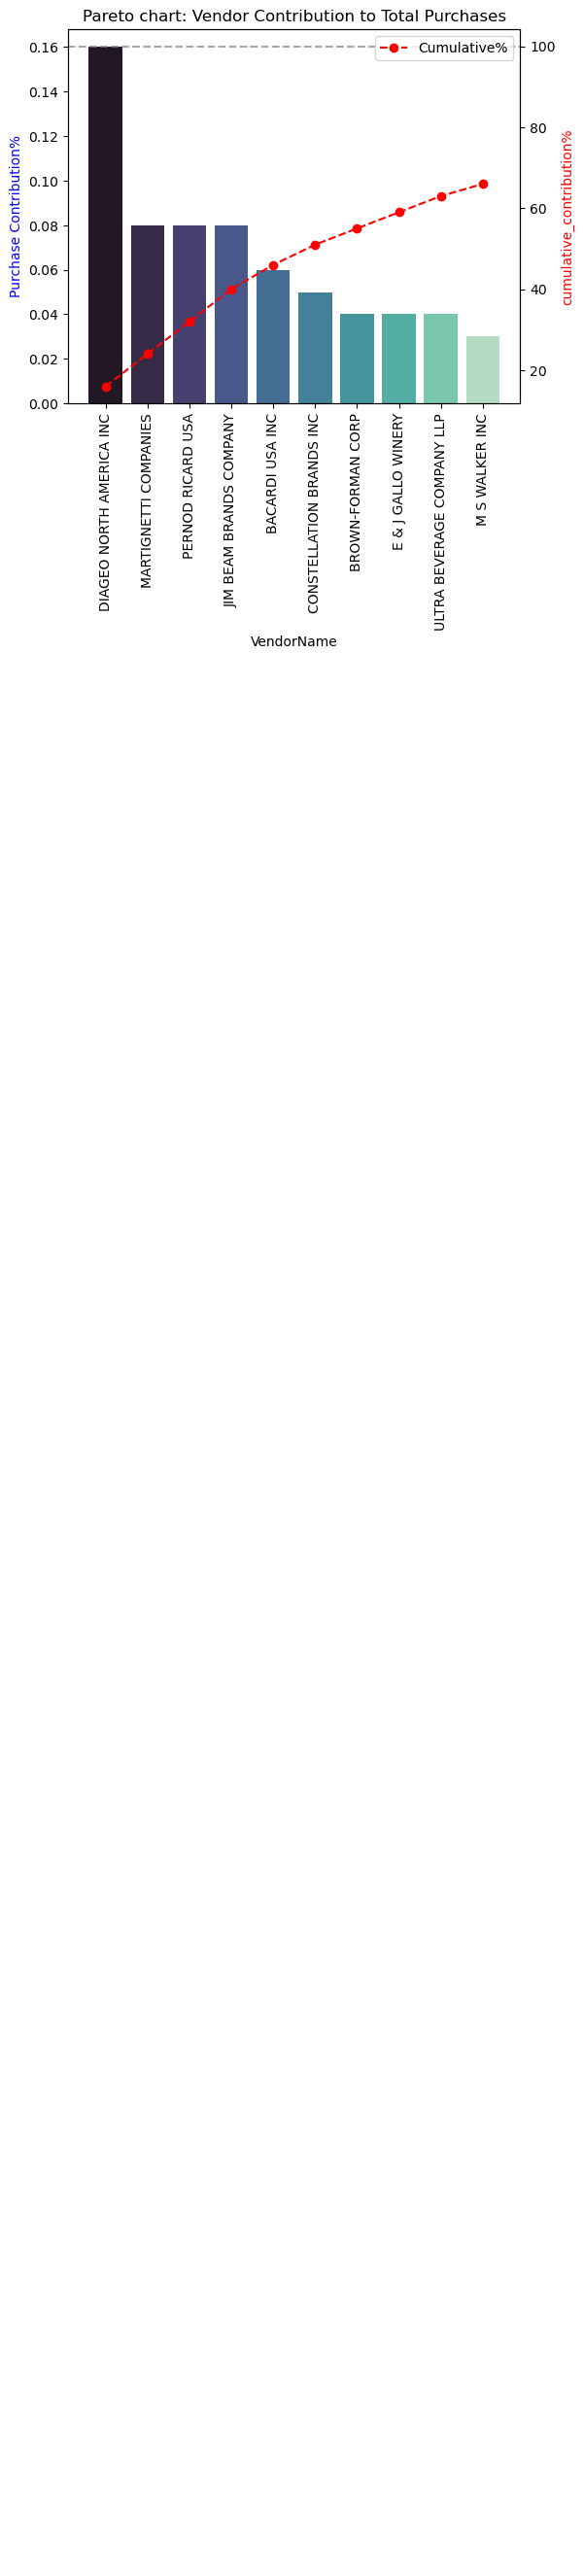

In [29]:
fig, ax1 = plt.subplots(figsize=(6,5))

sns.barplot(
    x=top_vendor["VendorName"],
    y=top_vendor["PurchaseContribution%"],
    palette="mako",
    ax=ax1,
)

for i, value in enumerate(top_vendor["PurchaseContribution%"]):
    ax1.text(
        i,
        value - 1,
        str(value) + "%",
        ha="center",
        fontsize=10,
        color="white",
    )

ax2 = ax1.twinx()
ax2.plot(
    top_vendor["VendorName"],
    top_vendor["cumulative_contribution%"],
    color="red",
    marker="o",
    linestyle="dashed",
    label="Cumulative%",
)

ax1.set_xticklabels(top_vendor["VendorName"], rotation=90)
ax1.set_ylabel("Purchase Contribution%", color="Blue")
# FIXED: Capitalized "Cumulative" to keep it clean
ax2.set_ylabel("cumulative_contribution%", color="Red")
ax2.set_xlabel("vendors")
ax1.set_title("Pareto chart: Vendor Contribution to Total Purchases")
ax2.axhline(y=100, color="grey", linestyle="dashed", alpha=0.7)
ax2.legend(loc="upper right")

plt.show()


In [30]:
# HOW MUCH OF TOTAL PROCUREMENT IS DEPENDENT ON THE TOP VENDORS?

In [31]:
print(f"Total Purchase Contribution of top10 vendor is {round(top_vendor["PurchaseContribution%"].sum(),2)*100}%")

Total Purchase Contribution of top10 vendor is 66.0%


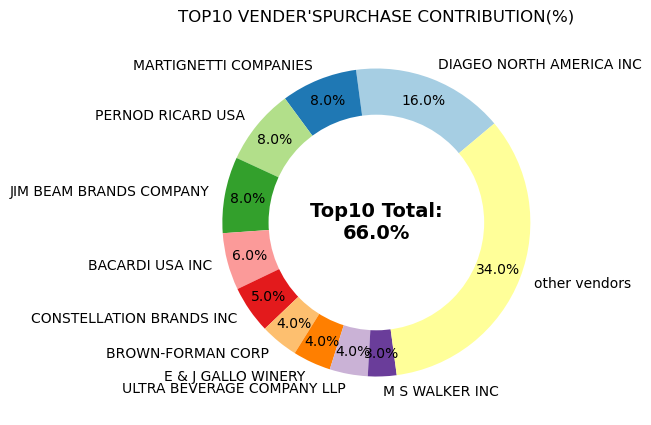

In [32]:
vendor = list(top_vendor["VendorName"].values)
purchase_contribution = list(top_vendor["PurchaseContribution%"].values)
total_contribution = sum(purchase_contribution)

# FIXED: If your total is 0.66%, your remaining is 99.34% (or 0.9934 if decimals)
# Change 100 to 1 if your data is stored as decimals (e.g., 0.0066)
if total_contribution <= 1:
    remaining_contribution = 1 - total_contribution
else:
    remaining_contribution = 100 - total_contribution

# Append "other vendor" category
vendor.append("other vendors")
purchase_contribution.append(remaining_contribution)

# DONUT CHART
fig, ax = plt.subplots(figsize=(8, 5))

# FIXED: Changed plt.CM.paired.colors to plt.cm.paired.colors
wedges, text, autotexts = ax.pie(
    purchase_contribution,
    labels=vendor,
    autopct="%1.1f%%",
    startangle=40,
    pctdistance=0.85,
    colors=plt.cm.get_cmap("Paired").colors,
)

# Optional: Add a center circle to actually make it a donut chart!
centre_circle = plt.Circle((0, 0), 0.70, fc="white")
fig.gca().add_artist(centre_circle)
#ADD Total Contribution annotation in the center
plt.text(0,0,f"Top10 Total:\n{total_contribution*100:.1f}%",fontsize=14,
         fontweight="bold",ha="center",va="center")
plt.title("TOP10 VENDER'SPURCHASE CONTRIBUTION(%)")
plt.show()

#### Does Purchasing in bulk reduce the unit Price, and what is the optiomal purchase volume for cost of savings. 

In [33]:
df["unitPurchasePrice"]=df["TotalPurchaseDollars"]/df["TotalPurchaseQuantity"]
df["ordersize"]=pd.qcut(df["TotalPurchaseQuantity"],q=3,labels=["small","medium","large"])
df.groupby("ordersize")["unitPurchasePrice"].mean()

ordersize
small     39.068186
medium    15.486414
large     10.777625
Name: unitPurchasePrice, dtype: float64

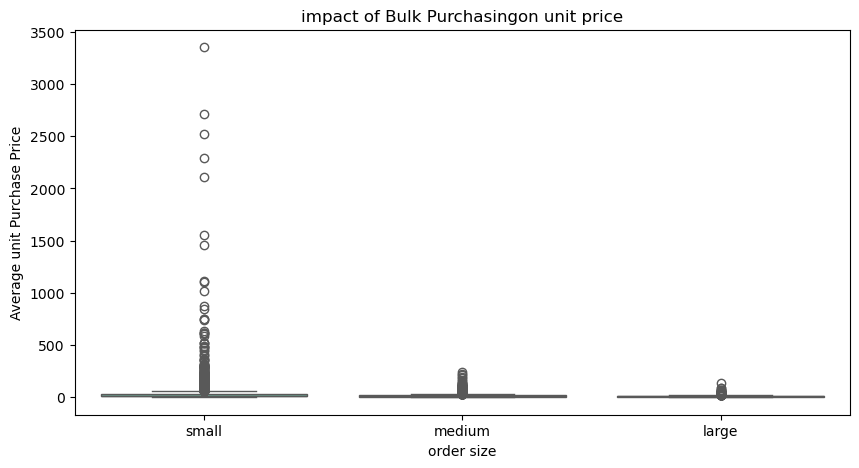

In [34]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df,x="ordersize",y="unitPurchasePrice",
            palette="Set2")
plt.title("impact of Bulk Purchasingon unit price")
plt.xlabel("order size")
plt.ylabel("Average unit Purchase Price")
plt.show()

### *Vendor buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.
### *The price difference between Small and Large orders is substantial (-72% reduction in unit cost).
### *This suggest that bulk pricing strategies successfully encourage vendors to purchase in larger volumnes leading to higher overall ales despite lower per_unit revenue.


In [35]:
# which vendors have low inventory turnoverindicating excess stocks and slow-moving product?

In [36]:
df.columns

Index(['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice',
       'ActualPrice', 'volume', 'TotalPurchaseQuantity',
       'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesDollars',
       'TotalSalesPrices', 'totalExciseTax', 'FreightCost', 'GrossProfit',
       'ProfitMargin', 'stockTurnover', 'SalesToPurchaseRatio',
       'unitPurchasePrice', 'ordersize'],
      dtype='object')

In [37]:
df[df["stockTurnover"] < 1].groupby("VendorName", as_index=False)["stockTurnover"].mean().sort_values(by="stockTurnover", ascending=True).head(10)

,VendorName,stockTurnover
0,ALISA CARR BEVERAGES,0.615385
36,HIGHLAND WINE MERCHANTS LLC,0.708333
60,PARK STREET IMPORTS LLC,0.751306
19,Circa Wines,0.755676
26,Dunn Wine Brokers,0.766022
15,CENTEUR IMPORTS LLC,0.773953
78,SMOKY QUARTZ DISTILLERY LLC,0.783835
90,TAMWORTH DISTILLING,0.797078
91,THE IMPORTED GRAPE LLC,0.807569
101,WALPOLE MTN VIEW WINERY,0.820548


In [38]:
# How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?

In [39]:
df["unsoldInventoryValue"]=(df["TotalPurchaseQuantity"]-df["TotalSalesQuantity"])*df["PurchasePrice"]

In [40]:
print("Total unsold Capital:",format_dollars(df["unsoldInventoryValue"].sum()))

Total unsold Capital: 2.71M


In [41]:
# Aggregate capitalLocked per Vender

In [42]:
inventory_value_per_vendor=df.groupby("VendorName")["unsoldInventoryValue"].sum().reset_index()
print(type(inventory_value_per_vendor["unsoldInventoryValue"]))

<class 'pandas.core.series.Series'>


In [43]:
# Sort vender with highest locked capital

In [44]:
inventory_value_per_vendor=inventory_value_per_vendor.sort_values(by="unsoldInventoryValue",ascending=False)

In [45]:
inventory_value_per_vendor["unsoldInventoryValue"]=inventory_value_per_vendor["unsoldInventoryValue"].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,unsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


In [46]:
# what is the 95% confidence intervalfor profit margins of top_perfoming and low_performing vendors

In [47]:
top_threshold=df["TotalSalesDollars"].quantile(0.75)
low_threshold=df["TotalSalesDollars"].quantile(0.25)
top_vendor=df[df["TotalSalesDollars"]>=top_threshold]["ProfitMargin"].dropna()
low_vendor=df[df["TotalSalesDollars"]<=low_threshold]["ProfitMargin"].dropna()

In [48]:
def confidence_interval(data,confidence=0.95):
    mean_val=np.mean(data)
    std_arr=np.std(data,ddof=1)/np.sqrt(len(data)) # standard error
    t_critical=stats.t.ppf((1+confidence)/2,df=len(data)-1)
    margin_of_error=t_critical=std_arr
    return mean_val,mean_val-margin_of_error,mean_val+margin_of_error

In [49]:
top_mean,top_lower,top_upper=confidence_interval(top_vendor)
low_mean,low_lower,low_upper=confidence_interval(low_vendor)
print(f"Top Vendor 95% CI:({top_lower:.2f},{top_upper:.2f},Mean:{top_mean:.2f})")
print(f"Low Vendor 95% CI:({low_lower:.2f},{low_upper:.2f},Mean:{low_mean:.2f})")

Top Vendor 95% CI:(30.96,31.40,Mean:31.18)
Low Vendor 95% CI:(41.02,42.11,Mean:41.57)


In [50]:
# Top Vendor Plot

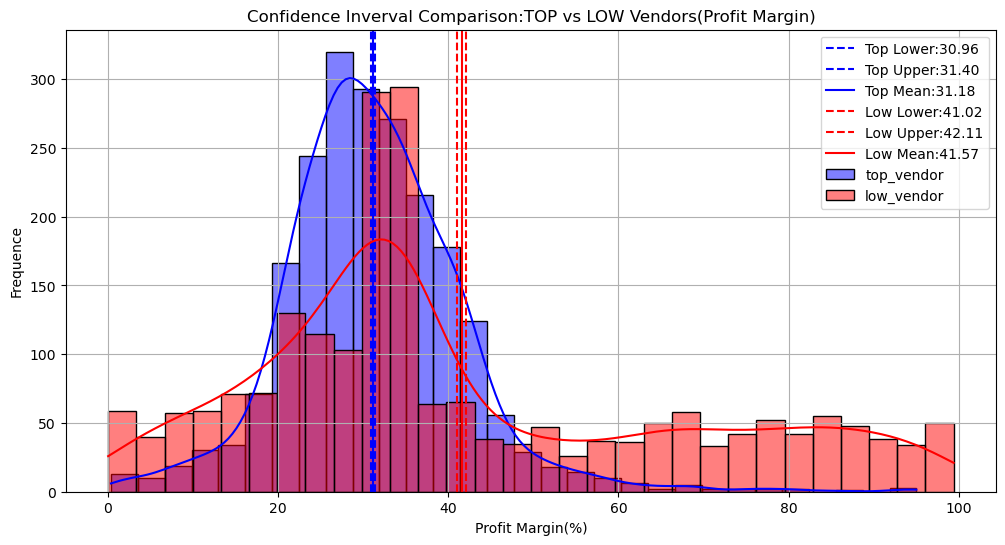

In [51]:
plt.figure(figsize=(12,6))
sns.histplot(top_vendor,kde=True,color="blue",bins=30,
             alpha=0.5,label="top_vendor")
plt.axvline(top_lower,color="blue",linestyle="--",label=f"Top Lower:{top_lower:.2f}")
plt.axvline(top_upper,color="blue",linestyle="--",label=f"Top Upper:{top_upper:.2f}")
plt.axvline(top_mean,color="blue",linestyle="-",label=f"Top Mean:{top_mean:.2f}")
#Low vendor Plot
sns.histplot(low_vendor,kde=True,color="red",bins=30,
             alpha=0.5,label="low_vendor")
plt.axvline(low_lower,color="red",linestyle="--",label=f"Low Lower:{low_lower:.2f}")
plt.axvline(low_upper,color="red",linestyle="--",label=f"Low Upper:{low_upper:.2f}")
plt.axvline(low_mean,color="red",linestyle="-",label=f"Low Mean:{low_mean:.2f}")
#finalize this plot
plt.title("Confidence Inverval Comparison:TOP vs LOW Vendors(Profit Margin)")
plt.xlabel("Profit Margin(%)")
plt.ylabel("Frequence")
plt.legend()
plt.grid(True)
plt.show()

### - The Confidence interval fior low_performing vendors:(40.48% to42.62%) is significantly higher that that of top_performing vendors(30.74% to 31.61%).
### -this suggests that vendors with lower sales tend to maintain higher profit margins,potentially due to premium pricing or lower operational costs.
### - for high-Performing vendors:if they aim to improve profitability, they could explore selective price adjustments, cost optimizations, or bundling strategies.
### - For low_performing vendors:despite Higher margins, their low sales volume might indicate a need for better marketing,competitive pricing , or improved distribution strategies.

## Is there a significant difference in profit margins betweentop_performing and low_performing Vendors?
### Hyporthesis:
#### * Ho(Null Hypothesis):there is no significant difference in the mean profit margins of top_performing  and low_performing vendors
#### * H1(Alternsative Hypothesis):the mean Proft Margins  of top_performing  and low_performing vendors are significantly different

In [52]:
top_threshold=df["TotalSalesDollars"].quantile(0.75)
low_threshold=df["TotalSalesDollars"].quantile(0.25)
top_vendor=df[df["TotalSalesDollars"]>=top_threshold]["ProfitMargin"].dropna()
low_vendor=df[df["TotalSalesDollars"]<=low_threshold]["ProfitMargin"].dropna()
#Performing two-sample T-test:
t_stat,p_value=ttest_ind(top_vendor,low_vendor,equal_var=False)
#print the results
print(f"T-statistics:{t_stat:4f},p_value:{p_value:.4f}")
if p_value<0.05:
    print("Reject Ho:there is a significant difference in profit margins between top and low performing vendors")
else:
    print("fail to reject Ho:No significant difference in profit margins.")

T-statistics:-17.669523,p_value:0.0000
Reject Ho:there is a significant difference in profit margins between top and low performing vendors


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8564 entries, 0 to 8563
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   VendorNumber           8564 non-null   int64   
 1   VendorName             8564 non-null   object  
 2   Brand                  8564 non-null   int64   
 3   Description            8564 non-null   object  
 4   PurchasePrice          8564 non-null   float64 
 5   ActualPrice            8564 non-null   float64 
 6   volume                 8564 non-null   float64 
 7   TotalPurchaseQuantity  8564 non-null   int64   
 8   TotalPurchaseDollars   8564 non-null   float64 
 9   TotalSalesQuantity     8564 non-null   float64 
 10  TotalSalesDollars      8564 non-null   float64 
 11  TotalSalesPrices       8564 non-null   float64 
 12  totalExciseTax         8564 non-null   float64 
 13  FreightCost            8564 non-null   float64 
 14  GrossProfit            8564 non-null   f

In [59]:
import pandas as pd
df.to_csv('Vendor Sales Summary.csv', index=False)

In [55]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,...,TotalSalesPrices,totalExciseTax,FreightCost,GrossProfit,ProfitMargin,stockTurnover,SalesToPurchaseRatio,unitPurchasePrice,ordersize,unsoldInventoryValue
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,...,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.27,large,79624.37
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,...,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,23.19,large,87913.29
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,...,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.24,large,4870.08
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,...,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.17,large,20535.90
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,...,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,21.89,large,49712.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,...,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667,1.32,small,-3.96
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,...,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829,0.39,small,-49.92
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,...,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838,0.74,small,0.00
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,...,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388,1.47,small,-104.37
